In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"paglaghoda","key":"Redacted"}'}

In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d limamateus/cic-iomt-2024-wifi-mqtt
!unzip cic-iomt-2024-wifi-mqtt.zip

Dataset URL: https://www.kaggle.com/datasets/limamateus/cic-iomt-2024-wifi-mqtt
License(s): apache-2.0
100% 276M/276M [00:04<00:00, 57.9MB/s]

Archive:  cic-iomt-2024-wifi-mqtt.zip
  inflating: CIC_IoMT_2024_WiFi_MQTT_test.csv  
  inflating: CIC_IoMT_2024_WiFi_MQTT_test.parquet  
  inflating: CIC_IoMT_2024_WiFi_MQTT_train.csv  
  inflating: CIC_IoMT_2024_WiFi_MQTT_train.parquet  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
train_df = pd.read_csv('CIC_IoMT_2024_WiFi_MQTT_train.csv')
test_df  = pd.read_csv('CIC_IoMT_2024_WiFi_MQTT_test.csv')

# Fix: strip _train / _test suffix from labels
train_df['label'] = train_df['label'].str.replace('_train', '', regex=False)
test_df['label']  = test_df['label'].str.replace('_test',  '', regex=False)

# Sample 20% to avoid crashes
train_df = train_df.sample(frac=0.2, random_state=42)
test_df  = test_df.sample(frac=0.2, random_state=42)

print("Train labels:", train_df['label'].unique()[:5])
print("Test labels:",  test_df['label'].unique()[:5])
print("Train shape:", train_df.shape)

Train labels: ['TCP_IP-DDoS-ICMP5' 'TCP_IP-DDoS-ICMP2' 'Recon-Port_Scan'
 'TCP_IP-DoS-UDP1' 'TCP_IP-DDoS-UDP8']
Test labels: ['TCP_IP-DoS-SYN' 'TCP_IP-DDoS-ICMP2' 'TCP_IP-DDoS-SYN' 'TCP_IP-DoS-ICMP'
 'TCP_IP-DoS-TCP']
Train shape: (1432166, 46)


In [ ]:
# Convert to binary: Benign = 0, anything else = 1
y_train = train_df['label'].apply(lambda x: 0 if x == 'Benign' else 1)
y_test  = test_df['label'].apply(lambda x: 0 if x == 'Benign' else 1)

X_train = train_df.drop(columns=['label'])
X_test  = test_df.drop(columns=['label'])

for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))

X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

print("✅ Preprocessed (binary)")
print("Attack vs Benign in train:")
print(y_train.value_counts())

✅ Preprocessed (binary)
Attack vs Benign in train:
label
1    1393854
0      38312
Name: count, dtype: int64


In [ ]:
model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    max_depth=15,
    verbose=1
)
model.fit(X_train, y_train)
joblib.dump(model, 'iomt_model_v2.pkl')
print("✅ Trained and saved!")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  2.2min


✅ Trained and saved!


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  2.3min finished


In [10]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.1s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    2.3s finished


Accuracy: 0.998466713749396
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      7525
           1       1.00      1.00      1.00    315311

    accuracy                           1.00    322836
   macro avg       0.98      0.98      0.98    322836
weighted avg       1.00      1.00      1.00    322836



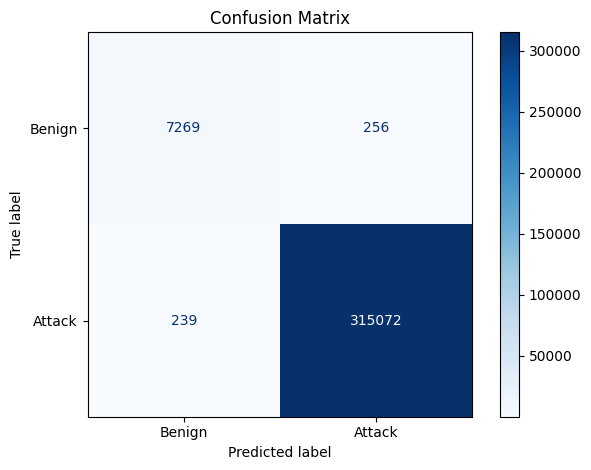

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

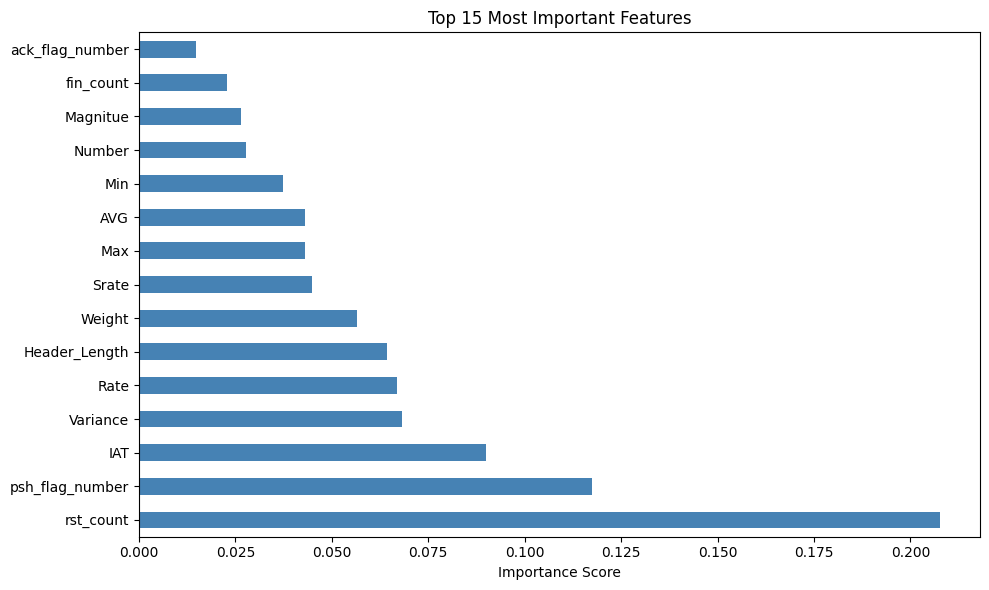

In [12]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.nlargest(15).plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()